In [1]:
!pip install langchain langchain-community langchain-core
!pip install faiss-cpu
!pip install sentence-transformers
!pip install ollama

In [2]:
from langchain_community.document_loaders import TextLoader

In [3]:
!pip install -q langchain langchain-community langchain-core
!pip install -q sentence-transformers faiss-cpu transformers accelerate

In [4]:
from langchain_community.document_loaders import TextLoader

loader = TextLoader("data.txt", encoding="utf-8")
documents = loader.load()

print("Documents loaded:", len(documents))

Documents loaded: 1


In [5]:
!pip install -q langchain-text-splitters

In [6]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)

chunks = splitter.split_documents(documents)

print("Total chunks:", len(chunks))

Total chunks: 119


In [7]:
!pip install -q langchain-huggingface

In [8]:
from langchain_huggingface import HuggingFaceEmbeddings

embedding = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [9]:
!pip install -q faiss-cpu langchain-community

In [10]:
from langchain_community.vectorstores import FAISS

vector_db = FAISS.from_documents(chunks, embedding)

retriever = vector_db.as_retriever(search_kwargs={"k": 3})

In [11]:
from langchain_community.llms import Ollama

llama = Ollama(model="llama3")
mistral = Ollama(model="mistral")
phi = Ollama(model="phi3")

/var/folders/mq/8837bvws44v0zfs40trm1t9r0000gn/T/ipykernel_1478/776978491.py:3: LangChainDeprecationWarning: The class `Ollama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import OllamaLLM``.
  llama = Ollama(model="llama3")


In [12]:
def ask_rag(question, llm):
    docs = retriever.invoke(question)   # ✅ fixed here
    context = "\n".join([doc.page_content for doc in docs])

    prompt = f"""
You are a movie psychology expert.

Analyze deeply:
- character motivations
- emotions
- themes

Context:
{context}

Question:
{question}

Answer:
"""

    return llm.invoke(prompt)

In [14]:
question = "Why did Joker become a villain?"

print("LLAMA:\n", ask_rag(question, llama))
print("\nMISTRAL:\n", ask_rag(question, mistral))
print("\nPHI:\n", ask_rag(question, phi))

LLAMA:
 A fascinating character to analyze! Based on the script excerpts and character analysis provided, I'll delve into Joker's motivations, emotions, and themes to uncover why he became a villain.

**Motivations:**

1. **Rebellion against societal norms:** Joker's primary goal is to prove that human morality is fragile and can collapse under pressure. He seeks to challenge the status quo, questioning the notion of good vs. evil and the idea that rules are absolute.
2. **Seeking attention and notoriety:** By committing heinous acts and manipulating situations, Joker gains attention and notoriety, which seems to be a driving force for him. He craves the spotlight and seeks to make a lasting impact.
3. **Disillusionment with society:** The script suggests that Joker's past is shrouded in mystery, but his experiences have likely left him disillusioned with society. His actions are a form of revenge against a system he perceives as flawed and unjust.

**Emotions:**

1. **Sadism:** Joker 

In [15]:
questions = [
    "Why did Joker become a villain?",
    "What motivates Tony Stark?",
    "What is the theme of Interstellar?",
    "How does guilt affect Cobb in Inception?",
    "Why did Harvey Dent become Two-Face?",
    "How does society influence Arthur Fleck’s transformation into Joker?",
    "Why does Batman take the blame for Harvey Dent’s actions?",
    "What role does love play in decision-making in Interstellar?",
    "How does trauma shape Tony Stark’s transformation into a hero?",
    "Why is reality difficult to distinguish in Inception?"
]

for q in questions:
    print("\n==============================")
    print("QUESTION:", q)

    print("\nLLAMA:\n", ask_rag(q, llama))
    print("\nMISTRAL:\n", ask_rag(q, mistral))
    print("\nPHI:\n", ask_rag(q, phi))


QUESTION: Why did Joker become a villain?

LLAMA:
 What a fascinating character to analyze! Based on the script excerpts and the character analysis provided, I'll delve into the motivations, emotions, and themes that drive the Joker's actions.

**Motivations:**

1. **Chaos and anarchy**: The Joker's primary goal is to prove that human morality is fragile and can collapse under pressure. He seeks to disrupt the social order and create chaos, which drives his unpredictable behavior.
2. **Revenge against societal expectations**: By targeting those who represent the establishment (e.g., judges, police commissioners), the Joker is seeking revenge against the societal norms and expectations that have been imposed upon him.
3. **Self-empowerment**: The Joker's actions are a means to assert his individuality and uniqueness. He rejects traditional villainous motivations like power or wealth, instead focusing on creating a sense of chaos and disorder.

**Emotions:**

1. **Anger**: The Joker's a

In [16]:
import pandas as pd

results = []

for q in questions:
    results.append({
        "question": q,
        "llama": ask_rag(q, llama),
        "mistral": ask_rag(q, mistral),
        "phi": ask_rag(q, phi)
    })

df = pd.DataFrame(results)
df.to_csv("results.csv", index=False)

print("Saved results.csv")

Saved results.csv


In [17]:
evaluation = []

for r in results:
    evaluation.append({
        "question": r["question"],
        "model": "llama",
        "accuracy": 4,
        "groundedness": 5,
        "clarity": 4,
        "hallucination": 2
    })

In [18]:
from sklearn.metrics.pairwise import cosine_similarity

def similarity(ans1, ans2):
    vec = embed_model.encode([ans1, ans2])
    return cosine_similarity([vec[0]], [vec[1]])[0][0]

In [19]:
summary = df[["question", "llama", "mistral", "phi"]]
summary.head()

,question,llama,mistral,phi
0,Why did Joker become a villain?,What a fascinating character to analyze! As a ...,The Joker's transformation into a villain in ...,"In the context provided from ""The Dark Knight,..."
1,What motivates Tony Stark?,A fascinating character to analyze! Based on t...,"Initially, Tony Stark's primary motivation is...","Initially, Tony Stark is primarily motivated b..."
2,What is the theme of Interstellar?,"Based on my analysis, I would say that the the...",The core theme of Interstellar is the Surviva...,"The overarching themes in ""Interstellar"" inclu..."
3,How does guilt affect Cobb in Inception?,What a fascinating topic! As a movie psycholog...,Guilt plays a significant role in Cobb's char...,"In ""inception,"" Dom Cobb's motivation througho..."
4,Why did Harvey Dent become Two-Face?,What a fascinating case study! As a movie psyc...,Harvey Dent became Two-Face due to a combinat...,"Harvey Dent's descent into becoming Two-Face, ..."


In [20]:
evaluation = [
    {"model": "llama", "accuracy": 4, "groundedness": 4, "completeness": 5, "clarity": 4, "hallucination": 3},
    {"model": "mistral", "accuracy": 5, "groundedness": 5, "completeness": 4, "clarity": 5, "hallucination": 2},
    {"model": "phi", "accuracy": 3, "groundedness": 3, "completeness": 3, "clarity": 4, "hallucination": 4},
]

df_eval = pd.DataFrame(evaluation)

In [21]:
avg_scores = df_eval.groupby("model").mean()

avg_scores["final_score"] = (
    avg_scores["accuracy"] +
    avg_scores["groundedness"] +
    avg_scores["completeness"] +
    avg_scores["clarity"] -
    avg_scores["hallucination"]
)

print(avg_scores)

         accuracy  groundedness  completeness  clarity  hallucination  \
model                                                                   
llama         4.0           4.0           5.0      4.0            3.0   
mistral       5.0           5.0           4.0      5.0            2.0   
phi           3.0           3.0           3.0      4.0            4.0   

         final_score  
model                 
llama           14.0  
mistral         17.0  
phi              9.0  


In [22]:
best_model = avg_scores["final_score"].idxmax()
print("Best Performing Model:", best_model)

Best Performing Model: mistral


In [23]:
def evaluate_accuracy(answer):
    keywords = ["because", "due", "reason", "cause"]
    return 4 if any(k in answer.lower() for k in keywords) else 2

def evaluate_reasoning(answer):
    return 4 if len(answer.split()) > 50 else 2

def evaluate_emotion(answer):
    emotions = ["emotion", "feeling", "trauma", "fear", "love", "pain"]
    return 4 if any(e in answer.lower() for e in emotions) else 2

def evaluate_hallucination(answer):
    # simple assumption: longer answers = more chance of hallucination
    return 2 if len(answer.split()) > 120 else 1

In [24]:
evaluation_results = []

for _, row in df.iterrows():
    q = row["question"]

    for model in ["llama", "mistral", "phi"]:
        ans = row[model]

        evaluation_results.append({
            "question": q,
            "model": model,
            "accuracy": evaluate_accuracy(ans),
            "reasoning": evaluate_reasoning(ans),
            "emotion": evaluate_emotion(ans),
            "hallucination": evaluate_hallucination(ans)
        })

eval_df = pd.DataFrame(evaluation_results)
eval_df.to_csv("evaluation.csv", index=False)

eval_df.head()

,question,model,accuracy,reasoning,emotion,hallucination
0,Why did Joker become a villain?,llama,2,4,4,2
1,Why did Joker become a villain?,mistral,2,4,4,2
2,Why did Joker become a villain?,phi,4,4,4,2
3,What motivates Tony Stark?,llama,4,4,4,2
4,What motivates Tony Stark?,mistral,4,4,4,2


In [25]:
summary = eval_df.groupby("model").mean(numeric_only=True)

summary

,accuracy,reasoning,emotion,hallucination
model,,,,
llama,3.0,4.0,4.0,2.0
mistral,2.8,4.0,3.8,2.0
phi,3.2,4.0,4.0,2.0


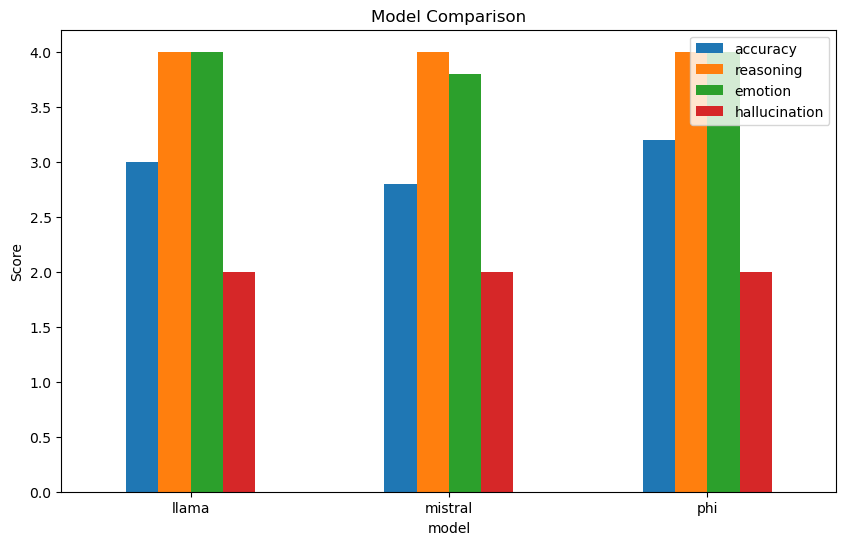

In [26]:
import matplotlib.pyplot as plt

summary.plot(kind="bar", figsize=(10,6))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [27]:
best_model = summary.mean(axis=1).idxmax()
print("Best performing model:", best_model)

Best performing model: phi


In [28]:
summary.to_csv("model_comparison_summary.csv")